关于此实验的介绍：
https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
import tensorflow as tf

from tensorflow import keras

print(tf.__version__)
print(sys.version_info)
for module in mpl, np, pd, sklearn, tf, keras:
    print(module.__name__, module.__version__)


2025-05-20 21:39:29.737792: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-20 21:39:29.748153: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-20 21:39:29.832423: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-20 21:39:29.910011: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747748369.967862    7269 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747748369.99

2.19.0
sys.version_info(major=3, minor=11, micro=2, releaselevel='final', serial=0)
matplotlib 3.10.3
numpy 2.1.3
pandas 2.2.3
sklearn 1.6.1
tensorflow 2.19.0
keras._tf_keras.keras 3.9.2


**为什么要分为训练集，验证集，测试集？**

原因在于开发模型时总是需要调节模型配置，比如选择层数或每层大小（这叫作模型的超参数（hyperparameter），以便与模型参数（即权重）区分开）。**这个调节过程需要使用模型在验证数据上的性能作为反馈信号。这个调节过程本质上就是一种学习**：在某个参数空间中寻找良好的模型配置。因此，如果基于模型在验证集上的性能来调节模型配置，会很快导致模型**在验证集上过拟合**，即使你并没有在验证集上直接训练模型也会如此。

造成这一现象的关键在于**信息泄露（information leak）**。每次基于模型在验证集上的性能来调节模型超参数，都会有一些关于验证数据的信息泄露到模型中。

In [2]:
# fashion_mnist 图像分类数据集
fashion_mnist = keras.datasets.fashion_mnist

(x_train_all, y_train_all), (x_test, y_test) = fashion_mnist.load_data()

x_valid, x_train = x_train_all[:5000], x_train_all[5000:]
y_valid, y_train = y_train_all[:5000], y_train_all[5000:]

# 得到的是 np，训练集，验证集，测试集
print(x_train.shape, y_train.shape)
print(x_valid.shape, y_valid.shape)
print(x_test.shape, y_test.shape)

(55000, 28, 28) (55000,)
(5000, 28, 28) (5000,)
(10000, 28, 28) (10000,)


In [3]:
type(x_train)

numpy.ndarray

In [4]:
y_train[3]  # 随便看一个值

np.uint8(9)

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   1   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  44 127 182 185 161 120  55
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  42 198 251 255 251 249 247 255 252
  214 100   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   2   0   0 233 252 237 239 234 237 235 237 237
  254 227   0   0   0   0   1   0   0   0]
 [  0   0   0   0   0   2   0   0  16 210 225 215 175 217 216 193 196 226
  221 209  50   0   0   2   0   0   0   0]
 [  0   0   0   0   2   0   0 199 229 232 230 245 204 219 253 245 207 194
  223 231 236 235   0   0   3   0   0   0]
 [  0   0   0   0   1   0 137 235 204 209 201 209 234 190 234 218 215 238
  239 204 189 224 154   0   0   0   0   0]
 [  0   0   0   0   0   0 194 201 200 209 202 193 205 194 183 218 231 197
  172 181 193 205 199   0   0   0   0   0]
 [  0   0   0   0   0   3 212 203 188 189 196 198 198 201 196 21

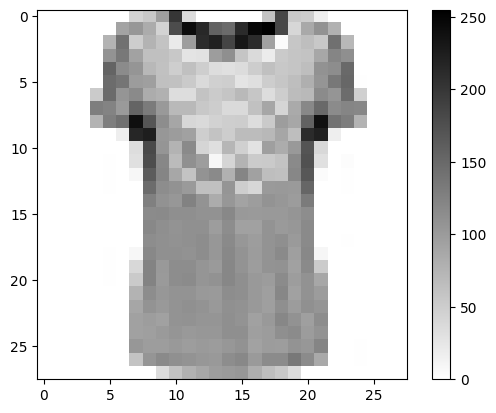

In [5]:
def show_single_image(img_arr):
    plt.imshow(img_arr, cmap="binary")
    plt.colorbar()  #旁边显示一个色阶条
    plt.show()

# 依次看一下 x_train[0]，x_train[1]，x_train[2]
print(x_train[0])
show_single_image(x_train[1])

In [6]:
print(x_train[1,0,18])
print(y_train[1])

184
0


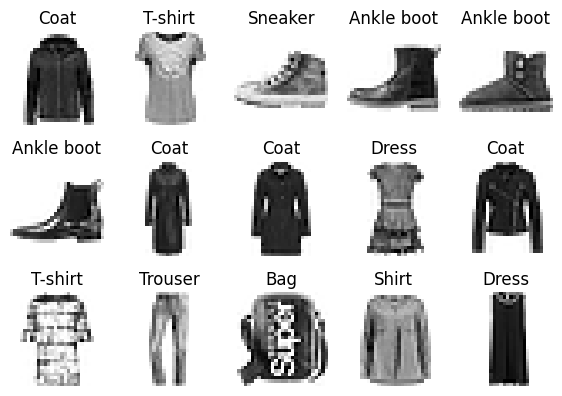

In [7]:
def show_imgs(n_rows, n_cols, x_data, y_data, class_names):
    assert len(x_data) == len(y_data)  # x和y的样本数一致
    assert n_rows * n_cols < len(x_data)  # 确保打印的图片小于总样本数
    plt.figure(figsize = (n_cols * 1.4, n_rows * 1.6))  # 宽1.4高1.6
    for row in range(n_rows):
        for col in range(n_cols):
            index = n_cols * row + col 
            plt.subplot(n_rows, n_cols, index+1) # 因为从1开始
            plt.imshow(x_data[index], cmap="binary", interpolation = 'nearest')
            plt.axis('off')#去除坐标系
            plt.title(class_names[y_data[index]])
    plt.show()

# 已知的图片类别
# lables在这个路径 https://github.com/zalandoresearch/fashion-mnist
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress',
               'Coat', 'Sandal', 'Shirt', 'Sneaker',
               'Bag', 'Ankle boot']
# 只是打印了前15个样本
show_imgs(3, 5, x_train, y_train, class_names)

In [8]:
# tf.keras.models.Sequential(),可以看下官网
# 功能：Sequential将线性的层堆叠到一个tf.keras.Model

model = keras.models.Sequential()
#把28*28的图片展平为一个一维向量,通过下面打印可以看到两个想乘
model.add(keras.layers.Flatten(input_shape=[28, 28]))
print(model.output_shape)

(None, 784)


/home/zhiyue/Documents/myvenv/tf/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
# Dense是全连接层，添加全连接层，单元数是 300，可以对比 300 和 100的差异
# relu: y = max(0, x)
# softmax: 将向量变成概率分布. x = [x1, x2, x3], 
#          y = [e^x1/sum, e^x2/sum, e^x3/sum], sum = e^x1 + e^x2 + e^x3
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))

# 或者可以直接简洁地写：
# model = keras.models.Sequential([
#     keras.layers.Flatten(input_shape=[28, 28]),
#     keras.layers.Dense(300, activation='relu'),
#     keras.layers.Dense(100, activation='relu'),
#     keras.layers.Dense(10, activation='softmax')
# ])

2025-05-20 21:39:32.536234: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


compile: Configures the model for training. 

see: https://www.tensorflow.org/api_docs/python/tf/keras/Sequential

In [10]:
# optimizer 是调整学习率的优化方法

# reason for sparse: y->index. y->one_hot->[] 
# loss是损失函数，y 如果只是一个数（例如计算的分类值是 0,1,2,...9），那么使用 sparse_categorical_crossentropy
# sparse_categorical_crossentropy 计算稀疏分类 crossentropy 损失。
# 如果是一个向量，那么使用 categorical_crossentropy

# metrics 模型在训练和测试期间要评估的指标列表

model.compile(loss="sparse_categorical_crossentropy",
              optimizer = keras.optimizers.SGD(0.001),  # 学习率是 0.001
              metrics = ["accuracy"])

**Cross Entropy 损失函数常用于分类问题中**，但是为什么它会在分类问题中这么有效呢？

**Mean Squared Error(均方误差)**，均方误差损失也是一种比较常见的损失函数，在分类问题中同样可以使用，但是在分类问题中，使用 sigmoid/softmax 得到概率，配合 MSE 损失函数时，采用梯度下降法进行学习时，会出现模型一开始训练时，**学习速率非常慢**的情况，这是因为它在衡量一个好模型和一个坏模型时，MSE 在数值上相差不大。

为此，提出**Cross Entropy Loss Function（交叉熵损失函数）**。

相对熵又称 KL 散度，如果我们对于同一个随机变量 x 有两个单独的概率分布 P(x) 和 Q(x)，我们可以使用 KL 散度（Kullback-Leibler (KL) divergence）来衡量这两个分布的差异。

KL 散度的计算公式：

$$
D_{KL}(p \| q) = \sum_{i=1}^{n} p(x_i) \log\left(\frac{p(x_i)}{q(x_i)}\right)
$$

其中，**P 表示样本的真实分布，Q 表示模型所预测的分布**，n 为事件的所有可能性个数。

$D_{KL}$ 的值越小，表示 q 分布和 p 分布越接近。

对公式变形可以得到：

$$
\begin{align*}
D_{KL}(p||q) &= \sum_{i=1}^{n} p(x_i) \log(p(x_i)) - \sum_{i=1}^{n} p(x_i) \log(q(x_i)) \\
&= -H(p(x)) + \left[ -\sum_{i=1}^{n} p(x_i) \log(q(x_i)) \right]
\end{align*}
$$

等式的前一部分恰巧就是 p 的熵，等式的后一部分，就是**交叉熵**：

$$
\begin{align*}
H(p, q) = - \sum_{i=1}^{n} p(x_i) \log(q(x_i))
\end{align*}
$$


我们需要评估 label 和 predicts 之间的差距，使用 KL 散度刚好，即 $D_{KL}(y \| \hat{y})$，由于 KL 散度中的前一部分 $-H(y)$ 不变，故在优化过程中，只需要关注交叉熵就可以了。所以一般在机器学习中直接用交叉熵做 loss，评估模型。

对于一个 batch 的 loss, m 为当前 batch 的样本数。MSE 的 loss :

$$
\text{loss} = \frac{1}{2m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2
$$

对于一个 batch 的 loss, m 为当前 batch 的样本数。交叉熵的 loss :

$$
\begin{align*}
\text{loss} = -\frac{1}{m} \sum_{j=1}^{m} \sum_{i=1}^{n} y_{ji} \log(\hat{y}_{ji})
\end{align*}
$$

In [11]:
model.layers  #总计有4层

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [12]:
# 算一下参数个数
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Output Shape 前面的 None 是样本数，目前没有输入样本，所以并不知道。

In [13]:
784*300+300

235500

In [14]:
300*100+100

30100

In [15]:
model.variables  # 模型中自己训练的参数（不是超参数）

[<Variable path=sequential/dense/kernel, shape=(784, 300), dtype=float32, value=[[ 0.06315437  0.0621224   0.02013108 ...  0.01566311 -0.05753832
   -0.01725052]
  [-0.00453912 -0.06895557 -0.00947954 ... -0.01218314 -0.01532164
    0.00471783]
  [-0.06587951 -0.01866237  0.06195846 ... -0.04091401 -0.06450759
    0.06873152]
  ...
  [ 0.00736857 -0.00671326  0.01405409 ... -0.00585473 -0.06910837
   -0.00235204]
  [-0.03887982  0.06591772 -0.07066814 ...  0.02482992 -0.06850395
   -0.06147449]
  [ 0.02506468 -0.04520588 -0.00745614 ...  0.0387731   0.00873347
   -0.04225733]]>,
 <Variable path=sequential/dense/bias, shape=(300,), dtype=float32, value=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

In [16]:
#均匀分布
np.sqrt(6/300)

np.float64(0.1414213562373095)

In [17]:
model.variables[0].numpy().max()

np.float32(0.07439767)

In [18]:
np.sqrt(6/100)

np.float64(0.2449489742783178)

In [19]:
model.variables[2].numpy().max()

np.float32(0.12246964)

In [20]:
55000/20

2750.0

In [21]:
# [None, 784] * W + b -> [None, 300] W.shape [784, 300], b = [300]
#W是矩阵，b是一个偏置，是一个向量

In [22]:
history = model.fit(x_train, y_train, epochs=20,
                    validation_data=(x_valid, y_valid))  
                    # 要通过验证集算损失、准确率
# batch_size 默认为 32

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6246 - loss: 14.0453 - val_accuracy: 0.7436 - val_loss: 0.6834
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7309 - loss: 0.6837 - val_accuracy: 0.7710 - val_loss: 0.6220
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7731 - loss: 0.5962 - val_accuracy: 0.8240 - val_loss: 0.5433
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8137 - loss: 0.5130 - val_accuracy: 0.8080 - val_loss: 0.5341
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8252 - loss: 0.4800 - val_accuracy: 0.8312 - val_loss: 0.5023
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8359 - loss: 0.4499 - val_accuracy: 0.8374 - val_loss: 0.4649
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8455 - loss: 0.4161 - val_accuracy: 0.8420 - val_loss: 0.4671
Epoch 8/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8478 - loss: 0.4081 

以下 5 种情况可供参考：
- train loss 不断下降，valid loss 不断下降，说明网络仍在学习（最好的）
- train loss 不断下降，valid loss 趋于不变，说明网络过拟合（max pool 或者正则化）
- train loss 趋于不变，valid loss 不断下降，说明数据集几乎 100% 有问题（检查 dataset）
- train loss 趋于不变，valid loss 趋于不变，说明学习遇到瓶颈
- train loss 不断上升，valid loss 不断上升，说明网络结构设计不当，训练超参数设置不当，数据集经过清洗等问题。

In [23]:
type(history)

keras.src.callbacks.history.History

In [24]:
#十次历史的信息
history.history

{'accuracy': [0.6753273010253906,
  0.7365090847015381,
  0.7842727303504944,
  0.8130909204483032,
  0.8267999887466431,
  0.8371272683143616,
  0.8432909250259399,
  0.8506545424461365,
  0.8546181917190552,
  0.8575090765953064,
  0.8616363406181335,
  0.863945484161377,
  0.8673272728919983,
  0.8685454726219177,
  0.8702909350395203,
  0.8722363710403442,
  0.8743636608123779,
  0.8752909302711487,
  0.8778908848762512,
  0.8788909316062927],
 'loss': [2.939093828201294,
  0.6730942726135254,
  0.5779551267623901,
  0.5123795866966248,
  0.471378892660141,
  0.44301632046699524,
  0.4203474521636963,
  0.4034046232700348,
  0.38953697681427,
  0.3792175054550171,
  0.36925092339515686,
  0.36168739199638367,
  0.3537929356098175,
  0.3484135866165161,
  0.34131699800491333,
  0.33627110719680786,
  0.33272480964660645,
  0.32816576957702637,
  0.32222670316696167,
  0.3180871903896332],
 'val_accuracy': [0.7436000108718872,
  0.7710000276565552,
  0.8240000009536743,
  0.808000028

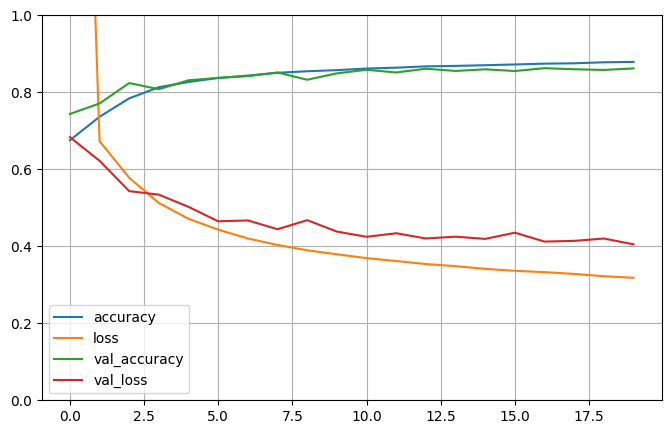

In [25]:
#画线要注意的是损失是不一定在零到1之间的
def plot_learning_curves(history):
    pd.DataFrame(history.history).plot(figsize=(8, 5))
    plt.grid(True)
    plt.gca().set_ylim(0, 1)
    plt.show()

plot_learning_curves(history)

In [26]:
model.evaluate(x_test, y_test, verbose=0)

[0.4605309069156647, 0.8460000157356262]

In [27]:
#计算标签和预测之间的crossentropy(交叉熵)损失
cce = keras.losses.SparseCategoricalCrossentropy()
loss = cce(
  [0, 1, 2],
  [[.9, .05, .05], [.05, .89, .06], [.05, .01, .94]])
print('Loss: ', loss.numpy())  

ValueError: Structures don't have the same nested structure.